# LSTM con atención (multiclase)

### Carga de dependencias y librerias

In [42]:
import pandas as pd
import torch
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.optim as optim
import spacy
import re
import gensim
from gensim.models import Word2Vec
from spellchecker import SpellChecker
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator
from torch.nn.utils.rnn import pad_sequence

Carga del Dataset

In [3]:
# Cargar el dataset
data = pd.read_csv(r"C:\Users\DELL\Downloads\LSTM+\jokes.csv")  # CAMBIAR LA RUTA DEL DATASET

### Paso 1: Preparación de Datos
La siguiente implementación, realiza el preprocesamiento de un conjunto de datos de "chistes", dividiéndolo en conjuntos de entrenamiento y validación, y transformando los datos en un formato adecuado para ser usados en un modelo de aprendizaje profundo. Incluye limpieza del texto mediante la normalización, eliminación de caracteres especiales, corrección ortográfica y manejo de valores nulos y duplicados. Luego, utiliza el modelo de spaCy para tokenizar los textos y crea un vocabulario que asigna índices a las palabras, manejando palabras desconocidas con un token especial. 

Aquí, se define un dataset personalizado que convierte cada texto en una secuencia de índices y sus etiquetas asociadas, junto con una función de colación que rellena las secuencias a una longitud uniforme. Finalmente, crea DataLoaders para los conjuntos de entrenamiento y validación, facilitando su uso en el entrenamiento y evaluación del modelo.

In [4]:
# Cargar el modelo de spaCy para español
nlp = spacy.load("es_core_news_sm")

# Limpieza y corrección ortográfica
def clean_data_with_spellcheck(data):
    # Inicializar corrector ortográfico para español
    spell = SpellChecker(language='es')

    # Seleccionar columnas relevantes
    data = data[['jokeText', 'jokeHasHumor', 'jokeRate']]

    # Manejar valores nulos
    data = data.dropna(subset=['jokeText', 'jokeHasHumor', 'jokeRate'])

    # Convertir columnas a tipos adecuados
    data['jokeHasHumor'] = data['jokeHasHumor'].astype(int)  # Para clasificación binaria
    data['jokeRate'] = data['jokeRate'].astype(int)          # Para clasificación multiclase

    # Remover duplicados
    data = data.drop_duplicates(subset=['jokeText'])

    # Normalizar el texto
    data['jokeText'] = data['jokeText'].str.lower()                # Convertir a minúsculas
    data['jokeText'] = data['jokeText'].str.replace(r'\s+', ' ', regex=True)  # Remover espacios extras
    data['jokeText'] = data['jokeText'].str.replace(r'[^a-zA-Z0-9\s]', '', regex=True)  # Remover caracteres especiales

    # Corregir errores ortográficos
    def correct_spelling(text):
        words = text.split()
        corrected_words = [
            spell.correction(word) if spell.correction(word) is not None else word for word in words
        ]
        return ' '.join(corrected_words)

    data['jokeText'] = data['jokeText'].apply(correct_spelling)

    return data

# Limpieza de los datos
data = clean_data_with_spellcheck(data)

# Dividir en conjuntos de entrenamiento y validación
train_data, val_data = train_test_split(data, test_size=0.2, random_state=42)

# Tokenizador con spaCy
def spacy_tokenizer(text):
    return [token.text for token in nlp(text)]

# Crear vocabulario
def yield_tokens(data_iter):
    for text in data_iter['jokeText']:
        yield spacy_tokenizer(text)

vocab = build_vocab_from_iterator(yield_tokens(train_data), specials=["<unk>"])
vocab.set_default_index(vocab["<unk>"])

# Convertir texto a índices
def text_pipeline(text):
    return [vocab[token] for token in spacy_tokenizer(text)]

# Dataset personalizado
class JokeDataset(Dataset):
    def __init__(self, data, target_col):
        self.data = data
        self.target_col = target_col

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        text = text_pipeline(self.data.iloc[idx]['jokeText'])
        label = self.data.iloc[idx][self.target_col]
        return torch.tensor(text, dtype=torch.long), torch.tensor(label, dtype=torch.long)

# Definir la función de colación personalizada
def collate_fn(batch):
    texts, labels = zip(*batch)  # Desempacar las tuplas en textos y etiquetas
    texts = [torch.tensor(text) for text in texts]  # Convertir textos en tensores
    texts_padded = pad_sequence(texts, batch_first=True, padding_value=0)  # Rellenar secuencias
    labels = torch.tensor(labels)  # Convertir etiquetas en tensor
    return texts_padded, labels

# Crear DataLoaders con la función de colación personalizada
train_dataset = JokeDataset(train_data, 'jokeHasHumor')
val_dataset = JokeDataset(val_data, 'jokeHasHumor')
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)


Se procede a verificar, visualmente y cuantitativamente los datos preprocesados en los conjuntos de entrenamiento (train_data) y validación (val_data). Aqui:

1. Se muestran algunas filas de train_data y val_data: Utilizando el método .head(), muestra las primeras cinco filas de cada conjunto de datos para inspeccionar cómo quedaron estructurados después del preprocesamiento (columnas y sus valores).

2. Se verifica el tamaño de los datasets: Usa la función len() para imprimir la cantidad total de registros en los conjuntos de entrenamiento y validación, lo que permite confirmar que la división de los datos se realizó correctamente y con el tamaño esperado. Esto es útil para asegurarse de que haya suficientes datos en cada conjunto para un entrenamiento y evaluación efectivos.

In [5]:
# Mostrar algunas filas de train_data y val_data
print("Train Data:\n", train_data.head())
print("Validation Data:\n", val_data.head())

# Verificar tamaño de los datasets
print("Tamaño de train_data:", len(train_data))
print("Tamaño de val_data:", len(val_data))

Train Data:
                                                jokeText  jokeHasHumor  \
9421  esto dos leproso borracho y uno le dije al otr...             1   
7469  es que caimito le dije a su papa papa papa te ...             0   
8402  como se llama tus nial la mayor cítara y la pe...             0   
257   doctor vendo a velo porque tenso un problema m...             0   
8062  mal en la escuela la mis me hijo que le presta...             0   

      jokeRate  
9421         2  
7469         1  
8402         1  
257          1  
8062         1  
Validation Data:
                                                jokeText  jokeHasHumor  \
5423  el seor estafa en el restaurante y llama al ca...             0   
93    tan dos gitano por el desierto y de repente un...             0   
8714  claro aquí tener un chiste con ese contexto po...             0   
2077  el profesor repartiendo las nota listo un diez...             1   
4154  camarero camarero me alma la ensalada con el u...        

Guardar los datos del preprocesamiento a un .csv como medida de punto de control futuro

In [10]:
# Exportar datos preprocesados a un archivo CSV
processed_data_path = "datos_preprocesados2.csv"  # Especificar el nombre del archivo

# Guardar datos preprocesados
data.to_csv(processed_data_path, index=False)

print(f"Datos preprocesados exportados exitosamente a {processed_data_path}")

Datos preprocesados exportados exitosamente a datos_preprocesados2.csv


Con la preparación de datos del dataset, ahora se procede a verificar la distribución grafica de los datos.

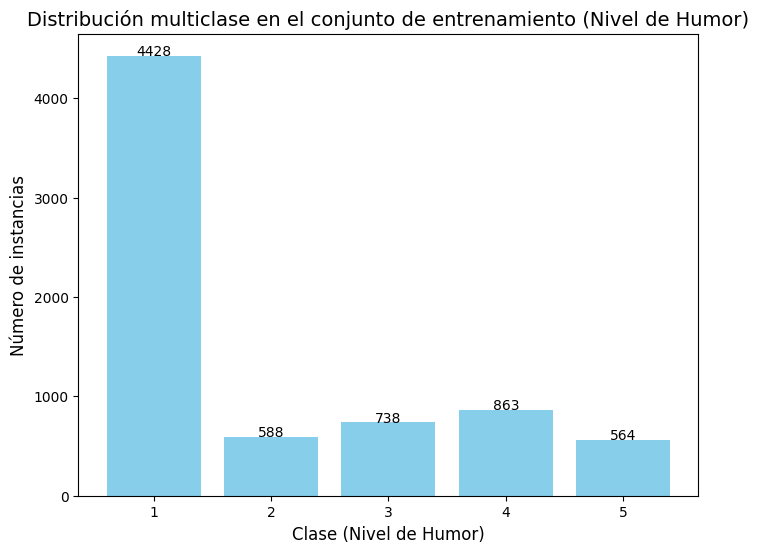

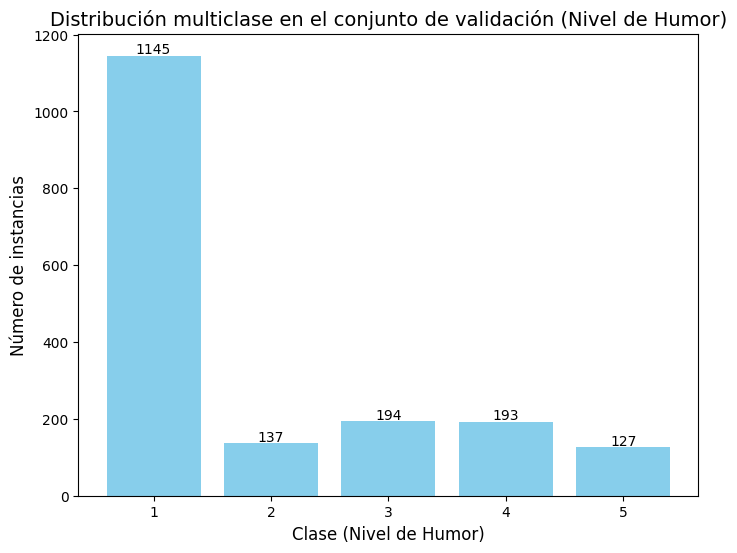

In [12]:
def plot_multiclass_distribution(data, title):
    # Contar las clases y asignar etiquetas
    class_counts = data['jokeRate'].value_counts().sort_index()  # Ordenar por índice para mantener el orden de las clases
    labels = class_counts.index.tolist()  # Obtener las clases como etiquetas
    counts = class_counts.values  # Obtener los conteos

    # Crear la gráfica de barras
    plt.figure(figsize=(8, 6))
    bars = plt.bar(labels, counts, color='skyblue')
    plt.xlabel("Clase (Nivel de Humor)", fontsize=12)
    plt.ylabel("Número de instancias", fontsize=12)
    plt.title(title, fontsize=14)

    # Etiquetas de los valores sobre las barras
    for bar, count in zip(bars, counts):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
                 str(count), ha='center', fontsize=10)

    plt.show()

# Graficar la distribución multiclase en los conjuntos de entrenamiento y validación
plot_multiclass_distribution(train_data, "Distribución multiclase en el conjunto de entrenamiento (Nivel de Humor)")
plot_multiclass_distribution(val_data, "Distribución multiclase en el conjunto de validación (Nivel de Humor)")

Aqui se verifica la distribución de datos del dataset, en el conjunto de datos multiclase

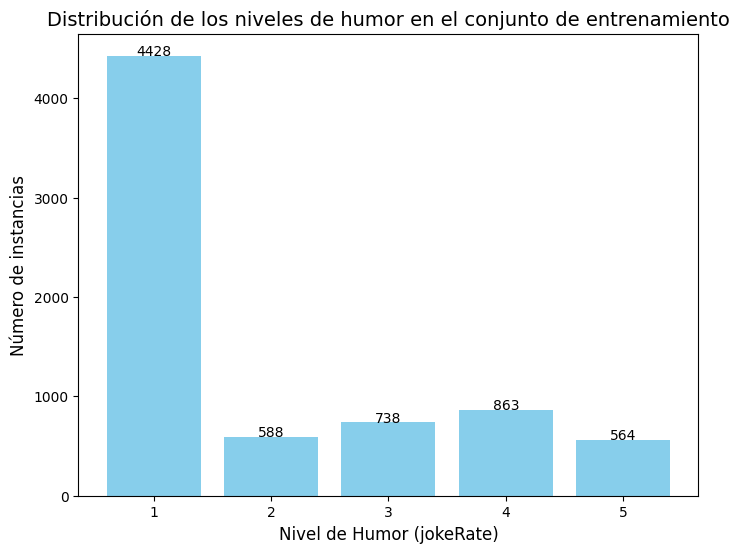

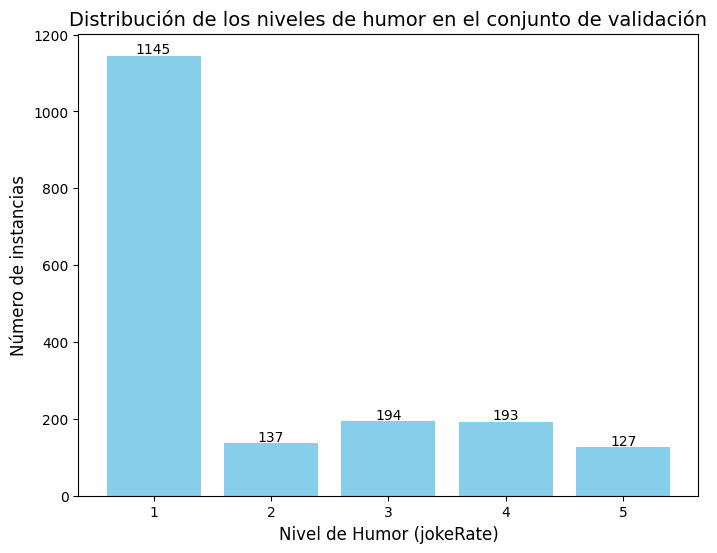

In [13]:
def plot_jokeRate_distribution(data, title):
    jokeRate_counts = data['jokeRate'].value_counts().sort_index()
    plt.figure(figsize=(8, 6))
    bars = plt.bar(jokeRate_counts.index, jokeRate_counts.values, color='skyblue')
    plt.xlabel("Nivel de Humor (jokeRate)", fontsize=12)
    plt.ylabel("Número de instancias", fontsize=12)
    plt.title(title, fontsize=14)
    plt.xticks(jokeRate_counts.index, fontsize=10)
    for bar in bars:
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
                 str(bar.get_height()), ha='center', fontsize=10)
    plt.show()

# Graficar la distribución en los conjuntos de entrenamiento y validación
plot_jokeRate_distribution(train_data, "Distribución de los niveles de humor en el conjunto de entrenamiento")
plot_jokeRate_distribution(val_data, "Distribución de los niveles de humor en el conjunto de validación")

Se procede a correlacionar los datos procesados, con embeddings preentrenaos de Word2Vec. En esta sección, se cargan embeddings preentrenados en español desde el preprocesamiento de datos anterior, creando una matriz de embeddings para representar palabras del vocabulario único extraído de los datos de entrenamiento, y prepara DataLoaders para manejar el flujo de datos hacia un modelo de aprendizaje profundo. 

Primero, se define una función para leer los embeddings desde el archivo y almacenarlos en un diccionario. Luego, se genera una matriz de embeddings donde cada palabra del vocabulario se mapea a su vector correspondiente, o a un vector aleatorio si no está presente en los embeddings preentrenados. Finalmente, se implementa un Dataset personalizado que convierte textos en índices basados en el vocabulario, y una función de colación que alinea las secuencias a una longitud común mediante relleno. 
Los DataLoaders generados permiten iterar sobre los datos en lotes durante el entrenamiento y la evaluación del modelo.

In [29]:
# Cargar los embeddings preentrenados en español desde archivo de texto
def load_word2vec_txt(path):
    embeddings_index = {}
    with open(path, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if i == 0:  # Ignorar la primera línea si contiene metadatos
                continue
            values = line.split()
            word = values[0]
            vector = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = vector
    return embeddings_index

# Ruta al archivo de embeddings
embedding_path = r"C:\Users\DELL\Downloads\LSTM+\SBW-vectors-300-min5.txt"  # Ruta de los embeddings preentrenados
word2vec_model = load_word2vec_txt(embedding_path)

# Crear la matriz de embeddings
embedding_dim = len(next(iter(word2vec_model.values())))
vocab = set(train_data['jokeText'].str.split().explode().unique())  # Extraer vocabulario único de los textos
embedding_matrix = torch.zeros((len(vocab), embedding_dim))
word_to_index = {word: idx for idx, word in enumerate(vocab)}

for word, idx in word_to_index.items():
    if word in word2vec_model:
        embedding_matrix[idx] = torch.tensor(word2vec_model[word])
    else:
        embedding_matrix[idx] = torch.randn(embedding_dim)  # Vector aleatorio si no está en Word2Vec

print("Matriz de embeddings creada correctamente.")

# 2. Preparar DataLoaders
def text_to_indices(text, word_to_index):
    return [word_to_index.get(word, 0) for word in text.split()]

# Actualizar Dataset personalizado
class JokeDataset(Dataset):
    def __init__(self, data, target_col):
        self.texts = data['jokeText']
        self.labels = data[target_col]

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text_indices = text_to_indices(self.texts.iloc[idx], word_to_index)
        label = self.labels.iloc[idx]
        return torch.tensor(text_indices, dtype=torch.long), torch.tensor(label, dtype=torch.long)  # Etiqueta como long para CrossEntropy

# Crear DataLoaders
def collate_fn(batch):
    texts, labels = zip(*batch)
    texts_padded = pad_sequence(
        [text if isinstance(text, torch.Tensor) else torch.tensor(text, dtype=torch.long) for text in texts],
        batch_first=True,
        padding_value=0
    )
    labels = torch.tensor(labels, dtype=torch.long)  # Convertir etiquetas en tensor de tipo long
    return texts_padded, labels

train_dataset = JokeDataset(train_data, 'jokeHasHumor')
val_dataset = JokeDataset(val_data, 'jokeHasHumor')

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)

print("DataLoaders preparados correctamente con los embeddings preentrenados.")

Matriz de embeddings creada correctamente.
DataLoaders preparados correctamente con los embeddings preentrenados.


A continuación, se evalúa qué proporción del vocabulario del modelo está cubierta por los embeddings preentrenados y detecta las palabras que están fuera de vocabulario (OOV). Calcula el porcentaje de cobertura del vocabulario en los embeddings, identifica las palabras que no tienen representación en los embeddings (oov_words) y muestra una muestra de las primeras 10 palabras OOV. Esto permite analizar la calidad de los embeddings en relación con el vocabulario del modelo y determinar si es necesario ajustar el preprocesamiento o entrenar embeddings adicionales.

In [30]:
# Calcular cobertura del vocabulario
vocab_coverage = sum(1 for word in vocab if word in word2vec_model) / len(vocab)
print(f"Coverage of vocabulary in embeddings: {vocab_coverage:.2%}")

# Mostrar palabras fuera de vocabulario
oov_words = [word for word in vocab if word not in word2vec_model]
print(f"Number of OOV words: {len(oov_words)}")
print("Sample OOV words:", oov_words[:10])

Coverage of vocabulary in embeddings: 73.02%
Number of OOV words: 3134
Sample OOV words: ['seoraeiou', 'hemoflico', 'agadón', 'chulama', 'babababab', 'alegrante', 'tronabaentraron', 'daygood', 'chinoviene', 'bracillo']


Luego, definimos una función clean_text para normalizar y limpiar los textos en el conjunto de datos. La función convierte el texto a minúsculas, simplifica risas exageradas (por ejemplo, "jajajaja" se reemplaza por "ja"), elimina caracteres no alfabéticos y normaliza los espacios múltiples a un solo espacio. Luego, aplica esta función de limpieza a las columnas jokeText en los conjuntos de entrenamiento (train_data) y validación (val_data) para garantizar que el texto esté limpio y uniforme antes de ser procesado por el modelo.

In [31]:
def clean_text(text):
    # Convertir a minúsculas
    text = text.lower()
    # Eliminar risas exageradas (jajajaja -> ja)
    text = re.sub(r'(ja|je|ji|jo|ju)+', 'ja', text)
    # Eliminar caracteres no alfabéticos
    text = re.sub(r'[^a-záéíóúñü\s]', '', text)
    # Eliminar múltiples espacios
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Aplicar limpieza a los datos
train_data['jokeText'] = train_data['jokeText'].apply(clean_text)
val_data['jokeText'] = val_data['jokeText'].apply(clean_text)

Posteriormente, se entrena un modelo de Word2Vec con el texto limpio del conjunto de entrenamiento (train_data['jokeText']), dividiéndolo en oraciones tokenizadas. Utiliza un vector de dimensión 300, una ventana de contexto de 5 palabras y requiere un mínimo de 1 aparición por palabra. 

A continuación, crea una matriz de embeddings personalizada donde cada palabra en el vocabulario (vocab) se asigna a su vector correspondiente generado por Word2Vec. Si una palabra del vocabulario no está en el modelo entrenado (w2v_model.wv), se asigna un vector aleatorio. La matriz resultante se utiliza como entrada para representar las palabras en el modelo de aprendizaje profundo.

In [32]:
# Entrenar embeddings con el texto limpio
sentences = train_data['jokeText'].str.split()
w2v_model = Word2Vec(sentences=sentences, vector_size=300, window=5, min_count=1, workers=4)

# Crear matriz de embeddings personalizada
embedding_dim = w2v_model.vector_size
embedding_matrix_custom = torch.zeros((len(vocab), embedding_dim))
for word, idx in word_to_index.items():
    if word in w2v_model.wv:
        embedding_matrix_custom[idx] = torch.tensor(w2v_model.wv[word])
    else:
        embedding_matrix_custom[idx] = torch.randn(embedding_dim)  # Vector aleatorio

### Paso 2: Definición del Modelo
A continuación, se configura y construye un modelo de aprendizaje profundo basado en LSTM con self-attention para tareas de clasificación, utilizando una configuración centralizada de hiperparámetros a través de la clase Config. El modelo incorpora embeddings preentrenados y personalizados concatenados en una matriz combinada. 

La arquitectura incluye una capa de embeddings ajustable, una LSTM con dropout, un mecanismo de self-attention para ponderar la importancia de las palabras, y una capa de clasificación final. También configura un optimizador Adam con diferentes tasas de aprendizaje para los embeddings y el resto del modelo, un DataLoader para preparar los datos, y un scheduler para ajustar dinámicamente la tasa de aprendizaje basado en la pérdida de validación. Finalmente, imprime los hiperparámetros utilizados para facilitar el seguimiento de las configuraciones del entrenamiento.

In [34]:
# Configuración centralizada de hiperparámetros
class Config:
    hidden_dim = 512
    dropout_prob = 0.3
    learning_rate_embeddings = 1e-5
    learning_rate_rest = 5e-4
    weight_decay = 1e-4
    batch_size = 32
    num_classes = len(data['jokeRate'].unique())  # Número de clases en jokeRate

# Modelo con Self-Attention
class LSTMSelfAttentionModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes, embedding_matrix, dropout_prob):
        super(LSTMSelfAttentionModel, self).__init__()
        self.embedding = nn.Embedding.from_pretrained(
            embedding_matrix.clone().detach(),
            freeze=False
        )
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.attention_weights = nn.Linear(hidden_dim, 1)
        self.dropout = nn.Dropout(dropout_prob)
        self.fc = nn.Linear(hidden_dim, num_classes)  # Salida ajustada a num_classes

    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, _ = self.lstm(embedded)
        lstm_out = self.dropout(lstm_out)
        attention_scores = self.attention_weights(lstm_out)
        attention_weights = torch.softmax(attention_scores, dim=1)
        context_vector = torch.sum(attention_weights * lstm_out, dim=1)
        context_vector = self.dropout(context_vector)
        output = self.fc(context_vector)
        return output

# Concatenar embeddings preentrenados y entrenados
embedding_matrix_combined = torch.cat((embedding_matrix, embedding_matrix_custom), dim=1)

# Definir el dispositivo de cómputo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Instanciar el modelo con Configuración centralizada
combined_embedding_dim = embedding_matrix_combined.shape[1]
model = LSTMSelfAttentionModel(
    vocab_size=len(vocab),
    embedding_dim=combined_embedding_dim,
    hidden_dim=Config.hidden_dim,
    num_classes=Config.num_classes,
    embedding_matrix=embedding_matrix_combined,
    dropout_prob=Config.dropout_prob
).to(device)

# Optimizador ajustado
optimizer = optim.Adam([
    {'params': model.embedding.parameters(), 'lr': Config.learning_rate_embeddings},
    {'params': model.lstm.parameters()},
    {'params': model.attention_weights.parameters()},
    {'params': model.fc.parameters()},
], lr=Config.learning_rate_rest, weight_decay=Config.weight_decay)

# DataLoaders ajustados
train_loader = DataLoader(train_dataset, batch_size=Config.batch_size, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=Config.batch_size, shuffle=False, collate_fn=collate_fn)

# Scheduler para ajuste dinámico de la tasa de aprendizaje
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.3, patience=5, verbose=True
)

# Mostrar los hiperparámetros utilizados
print(f"Hyperparameters: hidden_dim={Config.hidden_dim}, dropout_prob={Config.dropout_prob}, "
      f"learning_rate_embeddings={Config.learning_rate_embeddings}, learning_rate_rest={Config.learning_rate_rest}, "
      f"weight_decay={Config.weight_decay}, batch_size={Config.batch_size}")

Hyperparameters: hidden_dim=512, dropout_prob=0.3, learning_rate_embeddings=1e-05, learning_rate_rest=0.0005, weight_decay=0.0001, batch_size=32


### Paso 3: Entrenamiento
Aquí se implementa el entrenamiento de un modelo de aprendizaje profundo con LSTM y Self-Attention, calculando métricas clave como precisión, recall, F1-score y exactitud para evaluar su desempeño en cada época. La función calculate_metrics convierte las predicciones a valores binarios y calcula estas métricas comparándolas con las etiquetas verdaderas. 

La función principal, train_model_with_self_attention_and_scheduler, realiza el entrenamiento y la validación del modelo durante un número especificado de épocas. Registra las métricas y pérdidas de entrenamiento y validación, ajusta dinámicamente la tasa de aprendizaje usando un scheduler, y aplica "early stopping" si no se observa mejora en la pérdida de validación tras varias épocas consecutivas. Además, guarda el mejor estado del modelo durante el entrenamiento y restaura este estado al finalizar. Finalmente, devuelve un historial con las métricas y pérdidas registradas para su análisis posterior.

In [36]:
# Función para calcular métricas de evaluación
def calculate_metrics_multiclass(predictions, labels):
    preds = torch.argmax(predictions, dim=1).cpu().numpy()
    labels = labels.cpu().numpy()
    precision = precision_score(labels, preds, average='weighted', zero_division=0)
    recall = recall_score(labels, preds, average='weighted', zero_division=0)
    f1 = f1_score(labels, preds, average='weighted', zero_division=0)
    accuracy = accuracy_score(labels, preds)
    return precision, recall, f1, accuracy

# Función de entrenamiento
def train_model_with_self_attention_and_scheduler(
    model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=50, patience=8
):
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None  # Guardar el mejor modelo

    # Inicializar historial
    history = {
        'train_loss': [], 'val_loss': [],
        'train_precision': [], 'val_precision': [],
        'train_recall': [], 'val_recall': [],
        'train_f1': [], 'val_f1': [],
        'train_accuracy': [], 'val_accuracy': []
    }

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        all_train_predictions = []  # Corregido: inicializar como lista
        all_train_labels = []       # Corregido: inicializar como lista

        print(f"\nEpoch {epoch + 1}/{epochs}")

        for batch in train_loader:
            texts, labels = batch
            texts, labels = texts.to(device), labels.to(device)

            optimizer.zero_grad()
            predictions = model(texts)  # No uses .squeeze(1) para multiclase
            loss = criterion(predictions, labels)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            
            # Almacenar resultados en listas
            all_train_predictions.append(predictions.detach())  # Detach para evitar acumulación en el gráfico computacional
            all_train_labels.append(labels.detach())

        # Métricas de entrenamiento
        all_train_predictions = torch.cat(all_train_predictions)  # Concatenar al final
        all_train_labels = torch.cat(all_train_labels)
        train_precision, train_recall, train_f1, train_accuracy = calculate_metrics_multiclass(all_train_predictions, all_train_labels)

        # Actualizar historial de entrenamiento
        history['train_loss'].append(epoch_loss / len(train_loader))
        history['train_precision'].append(train_precision)
        history['train_recall'].append(train_recall)
        history['train_f1'].append(train_f1)
        history['train_accuracy'].append(train_accuracy)

        # Imprimir métricas de entrenamiento
        print(f"  Train Loss: {history['train_loss'][-1]:.4f}, Precision: {train_precision:.4f}, Recall: {train_recall:.4f}, F1: {train_f1:.4f}, Accuracy: {train_accuracy:.4f}")

        # Validación
        model.eval()
        val_loss = 0
        all_val_predictions = []  # Corregido: inicializar como lista
        all_val_labels = []       # Corregido: inicializar como lista

        with torch.no_grad():
            for batch in val_loader:
                texts, labels = batch
                texts, labels = texts.to(device), labels.to(device)
                predictions = model(texts)
                val_loss += criterion(predictions, labels).item()
                all_val_predictions.append(predictions)
                all_val_labels.append(labels)

        # Métricas de validación
        all_val_predictions = torch.cat(all_val_predictions)
        all_val_labels = torch.cat(all_val_labels)
        val_precision, val_recall, val_f1, val_accuracy = calculate_metrics_multiclass(all_val_predictions, all_val_labels)

        # Actualizar historial de validación
        history['val_loss'].append(val_loss / len(val_loader))
        history['val_precision'].append(val_precision)
        history['val_recall'].append(val_recall)
        history['val_f1'].append(val_f1)
        history['val_accuracy'].append(val_accuracy)

        # Imprimir métricas de validación
        print(f"  Val Loss: {history['val_loss'][-1]:.4f}, Precision: {val_precision:.4f}, Recall: {val_recall:.4f}, F1: {val_f1:.4f}, Accuracy: {val_accuracy:.4f}")

        # Scheduler para ajuste dinámico de la tasa de aprendizaje
        scheduler.step(val_loss)

        # Early Stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_model_state = model.state_dict()
            print(f"  Validation Loss improved to {best_val_loss:.4f}. Saving model...")
        else:
            patience_counter += 1
            print(f"  No improvement. Patience counter: {patience_counter}/{patience}")

        if patience_counter >= patience:
            print("Early stopping triggered!")
            break

    # Restaurar el mejor modelo
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print("Best model restored.")

    return history


# Función de pérdida
criterion = nn.CrossEntropyLoss()

# Entrenar el modelo
history = train_model_with_self_attention_and_scheduler(
    model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=50, patience=8
)


Epoch 1/50
  Train Loss: 0.7099, Precision: 0.5128, Recall: 0.5389, F1: 0.5028, Accuracy: 0.5389
  Val Loss: 0.6951, Precision: 0.7575, Recall: 0.4170, F1: 0.2474, Accuracy: 0.4170
  Validation Loss improved to 39.6201. Saving model...

Epoch 2/50
  Train Loss: 0.6919, Precision: 0.5210, Recall: 0.5512, F1: 0.4953, Accuracy: 0.5512
  Val Loss: 0.6860, Precision: 0.5510, Recall: 0.5846, F1: 0.4565, Accuracy: 0.5846
  Validation Loss improved to 39.1014. Saving model...

Epoch 3/50
  Train Loss: 0.6918, Precision: 0.4991, Recall: 0.5452, F1: 0.4671, Accuracy: 0.5452
  Val Loss: 0.6796, Precision: 0.5119, Recall: 0.5785, F1: 0.4515, Accuracy: 0.5785
  Validation Loss improved to 38.7358. Saving model...

Epoch 4/50
  Train Loss: 0.6879, Precision: 0.5092, Recall: 0.5439, F1: 0.4871, Accuracy: 0.5439
  Val Loss: 0.6779, Precision: 0.3417, Recall: 0.5841, F1: 0.4311, Accuracy: 0.5841
  Validation Loss improved to 38.6394. Saving model...

Epoch 5/50
  Train Loss: 0.6841, Precision: 0.5210,

### Paso 4: Evaluación
Esta implementación evalúa el desempeño de un modelo entrenado en función de diferentes umbrales (thresholds) utilizados para convertir las salidas continuas del modelo en predicciones binarias (0 o 1). La función evaluate_thresholds recorre una lista de umbrales especificados y calcula las métricas de evaluación (precisión, recall, F1-score y exactitud) para cada uno de ellos. 

Esto se hace aplicando la función sigmoide a las predicciones del modelo para obtener probabilidades y comparando estas probabilidades con cada umbral para decidir las clases predichas. Las métricas se calculan para las predicciones y las etiquetas verdaderas, y los resultados se almacenan en un diccionario por cada umbral. Finalmente, el script itera sobre estos resultados y los imprime, permitiendo analizar cómo varían las métricas dependiendo del umbral seleccionado. Esto es útil para optimizar el umbral según el caso de uso específico.

In [38]:
# Evaluar diferentes thresholds (corregido para multiclase)
def evaluate_thresholds_multiclass(model, data_loader):
    model.eval()
    results = {"precision": [], "recall": [], "f1": [], "accuracy": []}
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for texts, labels in data_loader:
            texts, labels = texts.to(device), labels.to(device)
            predictions = model(texts)
            all_predictions.append(predictions)  # Sin umbrales
            all_labels.append(labels)

    # Concatenar todas las predicciones y etiquetas
    all_predictions = torch.cat(all_predictions)
    all_labels = torch.cat(all_labels)

    # Convertir logits/probabilidades a etiquetas de clase
    predicted_labels = torch.argmax(all_predictions, dim=1).cpu().numpy()
    true_labels = all_labels.cpu().numpy()

    # Calcular métricas
    precision = precision_score(true_labels, predicted_labels, average="weighted", zero_division=0)
    recall = recall_score(true_labels, predicted_labels, average="weighted", zero_division=0)
    f1 = f1_score(true_labels, predicted_labels, average="weighted", zero_division=0)
    accuracy = accuracy_score(true_labels, predicted_labels)

    results["precision"] = precision
    results["recall"] = recall
    results["f1"] = f1
    results["accuracy"] = accuracy

    return results

# Evaluar modelo en el conjunto de validación
results = evaluate_thresholds_multiclass(model, val_loader)
print(f"Precision: {results['precision']:.4f}, Recall: {results['recall']:.4f}, F1: {results['f1']:.4f}, Accuracy: {results['accuracy']:.4f}")

Precision: 0.5176, Recall: 0.5690, F1: 0.4831, Accuracy: 0.5690


### Análisis cuantitativo detallado
Esta sección, realiza dos tareas principales: graficar las métricas de entrenamiento y validación, y mostrar una matriz de confusión normalizada basada en los resultados de validación del modelo. 

La función plot_metrics genera gráficos comparativos entre entrenamiento y validación para pérdida, precisión, recall y F1-score, destacando cómo evolucionan estas métricas a lo largo de las épocas de entrenamiento. Verifica que los datos correspondientes estén disponibles en el historial antes de graficar. La función plot_confusion_matrix, por otro lado, evalúa el modelo en el conjunto de validación, recopila las predicciones y etiquetas verdaderas, calcula una matriz de confusión normalizada y la presenta visualmente con etiquetas 'No Humor' y 'Humor', ayudando a entender el desempeño del modelo en términos de clasificación correcta e incorrecta. 

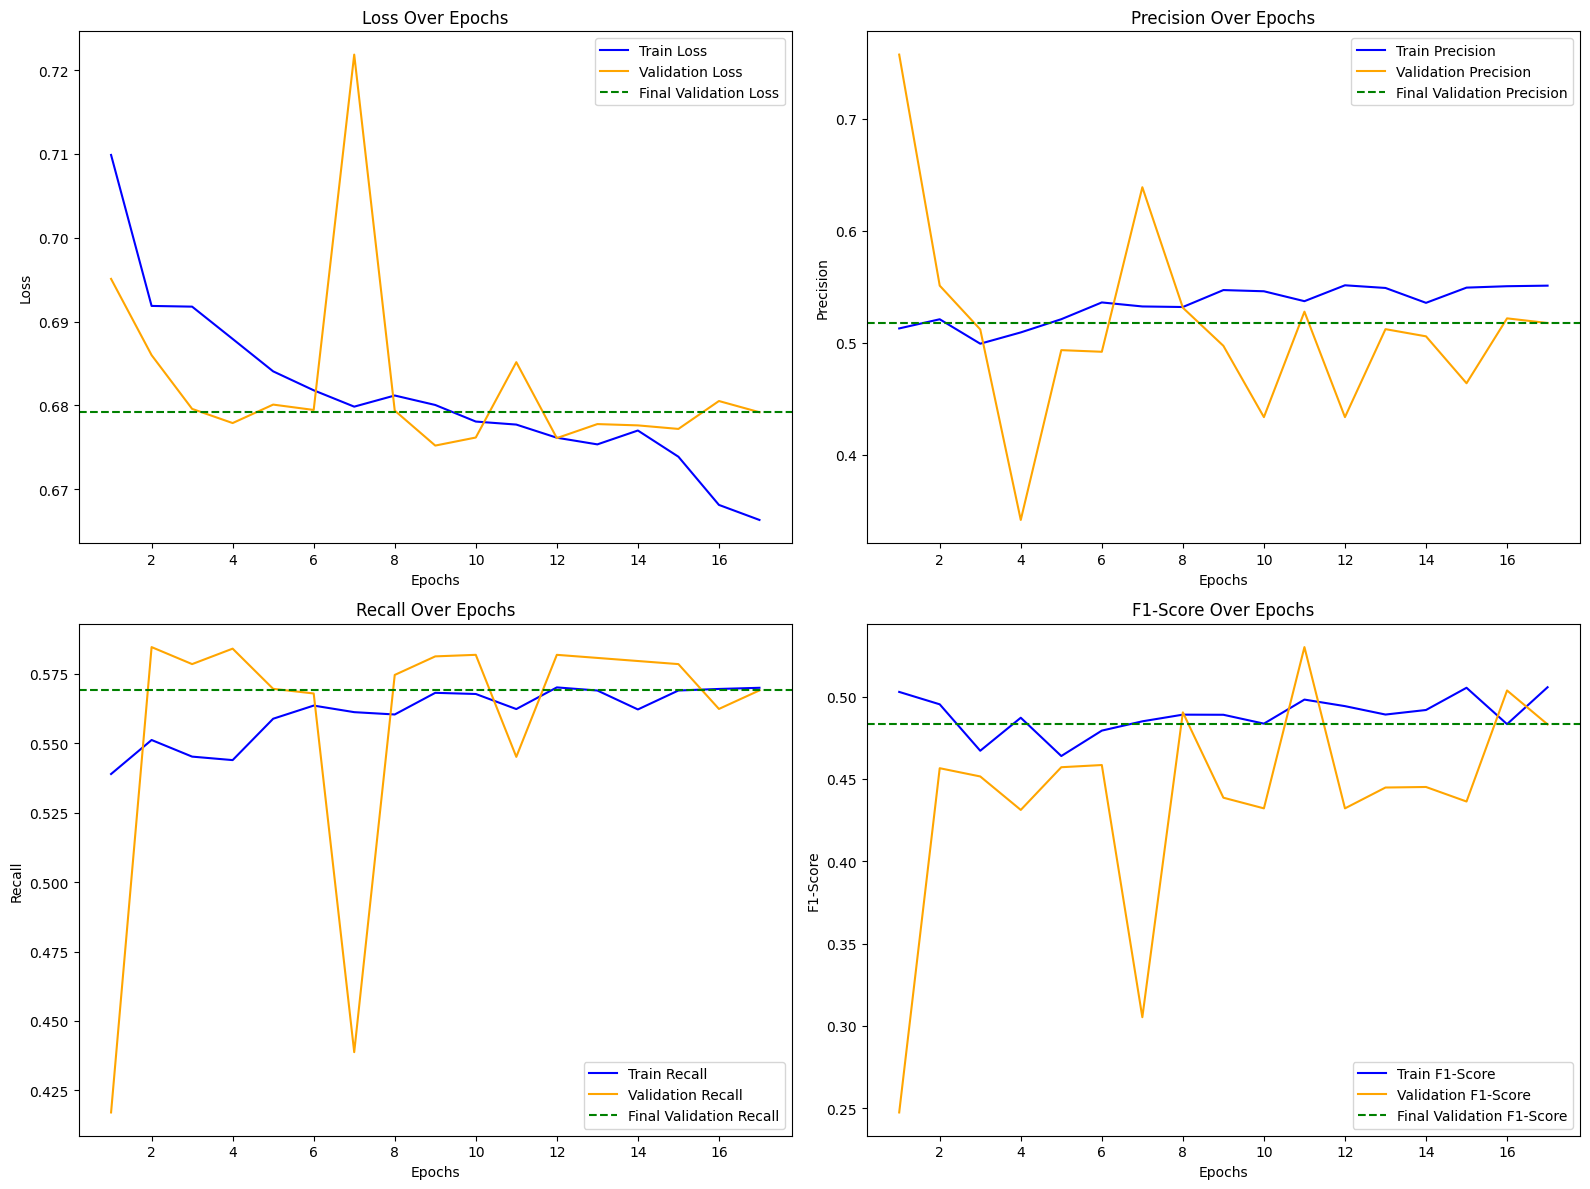

In [39]:
# Función actualizada para graficar métricas con evaluación final
def plot_metrics_with_evaluation(history):
    epochs = len(history['train_loss'])

    plt.figure(figsize=(16, 12))

    # Pérdida
    plt.subplot(2, 2, 1)
    plt.plot(range(1, epochs + 1), history['train_loss'], label='Train Loss', color='blue')
    plt.plot(range(1, epochs + 1), history['val_loss'], label='Validation Loss', color='orange')
    plt.axhline(history['val_loss'][-1], color='green', linestyle='--', label='Final Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Loss Over Epochs')
    plt.legend()

    # Precisión
    plt.subplot(2, 2, 2)
    plt.plot(range(1, epochs + 1), history['train_precision'], label='Train Precision', color='blue')
    plt.plot(range(1, epochs + 1), history['val_precision'], label='Validation Precision', color='orange')
    plt.axhline(history['val_precision'][-1], color='green', linestyle='--', label='Final Validation Precision')
    plt.xlabel('Epochs')
    plt.ylabel('Precision')
    plt.title('Precision Over Epochs')
    plt.legend()

    # Recall
    plt.subplot(2, 2, 3)
    plt.plot(range(1, epochs + 1), history['train_recall'], label='Train Recall', color='blue')
    plt.plot(range(1, epochs + 1), history['val_recall'], label='Validation Recall', color='orange')
    plt.axhline(history['val_recall'][-1], color='green', linestyle='--', label='Final Validation Recall')
    plt.xlabel('Epochs')
    plt.ylabel('Recall')
    plt.title('Recall Over Epochs')
    plt.legend()

    # F1-Score
    plt.subplot(2, 2, 4)
    plt.plot(range(1, epochs + 1), history['train_f1'], label='Train F1-Score', color='blue')
    plt.plot(range(1, epochs + 1), history['val_f1'], label='Validation F1-Score', color='orange')
    plt.axhline(history['val_f1'][-1], color='green', linestyle='--', label='Final Validation F1-Score')
    plt.xlabel('Epochs')
    plt.ylabel('F1-Score')
    plt.title('F1-Score Over Epochs')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Llamar a la función para graficar métricas
plot_metrics_with_evaluation(history)

Finalmente, se genera y visualiza una matriz de confusión para evaluar el desempeño de un modelo de clasificación binaria en el conjunto de datos de validación. La función plot_confusion_matrix utiliza el modelo entrenado para realizar predicciones sobre los datos del data_loader, convirtiendo las probabilidades generadas por la función sigmoide en predicciones binarias con un umbral de 0.5. Estas predicciones se comparan con las etiquetas reales para calcular la matriz de confusión, que muestra las relaciones entre predicciones correctas e incorrectas para ambas clases ("No Humor" y "Humor"). Finalmente, la matriz se visualiza utilizando ConfusionMatrixDisplay, lo que permite identificar patrones de error del modelo.

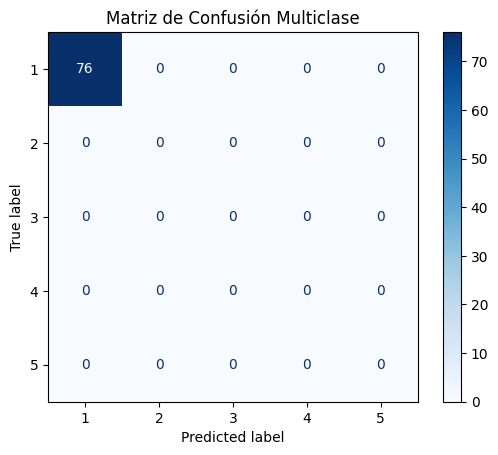

In [41]:
# Generar matriz de confusión multiclase corregida
def plot_confusion_matrix_multiclass(model, data_loader, class_labels):
    model.eval()
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for texts, labels in data_loader:
            texts, labels = texts.to(device), labels.to(device)
            predictions = model(texts)
            all_predictions.append(torch.argmax(predictions, dim=1).cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    # Concatenar todas las predicciones y etiquetas
    all_predictions = np.concatenate(all_predictions)
    all_labels = np.concatenate(all_labels)

    # Generar matriz de confusión
    cm = confusion_matrix(all_labels, all_predictions, labels=class_labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
    disp.plot(cmap=plt.cm.Blues)
    plt.title("Matriz de Confusión Multiclase")
    plt.show()

# Obtener etiquetas de clases de los datos de validación
class_labels = sorted(train_data['jokeRate'].unique())  # Clases presentes en los datos
plot_confusion_matrix_multiclass(model, val_loader, class_labels)